In [1]:
# ==========================================
# Student Dropout Prediction System
# MIT Final Project
# Notebook 3: Model Training
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

import joblib

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving student_dropout_v3.csv to student_dropout_v3.csv
Saving student_dropout_v2.csv to student_dropout_v2.csv
Saving student_dropout_v1.csv to student_dropout_v1.csv


In [5]:
v1 = pd.read_csv("student_dropout_v1.csv")

v2 = pd.read_csv("student_dropout_v2.csv")

v3 = pd.read_csv("student_dropout_v3.csv")

In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else predictions

    return {

        "Accuracy": accuracy_score(y_test,predictions),

        "Precision": precision_score(y_test,predictions),

        "Recall": recall_score(y_test,predictions),

        "F1": f1_score(y_test,predictions),

        "ROC_AUC": roc_auc_score(y_test,probabilities)

    }

In [7]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Support Vector Machine":
        SVC(
            probability=True,
            random_state=42
        )

}

In [8]:
def run_dataset(df, dataset_name):

    X = df.drop("Dropout", axis=1)

    y = df["Dropout"]

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.20,

        random_state=42,

        stratify=y

    )

    results = []

    trained_models = {}

    for name, model in models.items():

        metrics = evaluate_model(

            model,

            X_train,

            X_test,

            y_train,

            y_test

        )

        metrics["Dataset"] = dataset_name

        metrics["Model"] = name

        results.append(metrics)

        trained_models[name] = model

    return pd.DataFrame(results), trained_models

In [9]:
results_v1, trained_v1 = run_dataset(v1,"Version 1")

results_v2, trained_v2 = run_dataset(v2,"Version 2")

results_v3, trained_v3 = run_dataset(v3,"Version 3")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
results = pd.concat(

    [

        results_v1,

        results_v2,

        results_v3

    ],

    ignore_index=True

)

results

,Accuracy,Precision,Recall,F1,ROC_AUC,Dataset,Model
0,0.8140,0.670103,0.414013,0.511811,0.817957,Version 1,Logistic Regression
1,0.7125,0.388412,0.384289,0.386339,0.598946,Version 1,Decision Tree
2,0.8070,0.657993,0.375796,0.478378,0.803307,Version 1,Random Forest
3,0.8055,0.644366,0.388535,0.484768,0.816038,Version 1,Gradient Boosting
4,0.7645,0.000000,0.000000,0.000000,0.507084,Version 1,Support Vector Machine
5,0.8130,0.672598,0.401274,0.502660,0.820966,Version 2,Logistic Regression
6,0.7185,0.407258,0.428875,0.417787,0.618296,Version 2,Decision Tree
7,0.8050,0.643110,0.386412,0.482759,0.802326,Version 2,Random Forest
8,0.8075,0.651408,0.392781,0.490066,0.812886,Version 2,Gradient Boosting
9,0.8045,0.675439,0.326964,0.440629,0.760243,Version 2,Support Vector Machine


In [11]:
results = results.sort_values(

    by="Accuracy",

    ascending=False

)

results

,Accuracy,Precision,Recall,F1,ROC_AUC,Dataset,Model
0,0.8140,0.670103,0.414013,0.511811,0.817957,Version 1,Logistic Regression
10,0.8140,0.674912,0.405520,0.506631,0.817879,Version 3,Logistic Regression
5,0.8130,0.672598,0.401274,0.502660,0.820966,Version 2,Logistic Regression
8,0.8075,0.651408,0.392781,0.490066,0.812886,Version 2,Gradient Boosting
12,0.8070,0.646048,0.399151,0.493438,0.796351,Version 3,Random Forest
2,0.8070,0.657993,0.375796,0.478378,0.803307,Version 1,Random Forest
3,0.8055,0.644366,0.388535,0.484768,0.816038,Version 1,Gradient Boosting
7,0.8050,0.643110,0.386412,0.482759,0.802326,Version 2,Random Forest
9,0.8045,0.675439,0.326964,0.440629,0.760243,Version 2,Support Vector Machine
14,0.8040,0.674009,0.324841,0.438395,0.758989,Version 3,Support Vector Machine


In [12]:
results.to_csv(

    "model_comparison.csv",

    index=False

)

In [13]:
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
best_dataset = results.iloc[0]["Dataset"]

best_model_name = results.iloc[0]["Model"]

print(best_dataset)

print(best_model_name)

Version 1
Logistic Regression


In [15]:
trained_lookup = {
    "Version 1": trained_v1,
    "Version 2": trained_v2,
    "Version 3": trained_v3
}

best_model = trained_lookup[best_dataset][best_model_name]

In [16]:
joblib.dump(best_model,"best_model.pkl")

['best_model.pkl']

In [17]:
files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

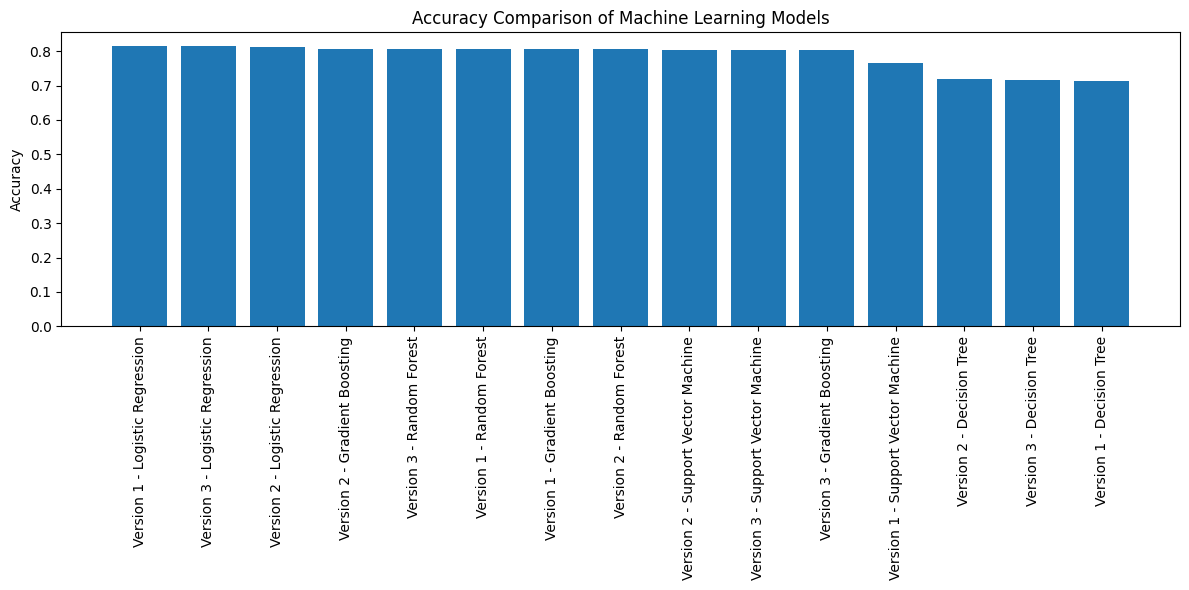

In [18]:
plt.figure(figsize=(12,6))

plt.bar(

    results["Dataset"] + " - " + results["Model"],

    results["Accuracy"]

)

plt.xticks(rotation=90)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison of Machine Learning Models")

plt.tight_layout()

plt.show()

In [41]:
print("Best Dataset:", best_dataset)
print("Best Model:", best_model_name)

Best Dataset: Version 1
Best Model: Logistic Regression


In [42]:
print(best_model.feature_names_in_)

['GPA' 'Academic_Performance' 'CGPA' 'Semester_GPA' 'Attendance_Rate'
 'Academic_Risk' 'Stress_Index' 'Study_Efficiency' 'Study_Hours_per_Day'
 'Age' 'Travel_Time_Minutes' 'Accessibility_Score' 'Family_Income'
 'Assignment_Delay_Days' 'Department']


In [43]:
print(best_df.columns.tolist())


['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']


In [44]:
results.head(15)

,Accuracy,Precision,Recall,F1,ROC_AUC,Dataset,Model
0,0.8140,0.670103,0.414013,0.511811,0.817957,Version 1,Logistic Regression
10,0.8140,0.674912,0.405520,0.506631,0.817879,Version 3,Logistic Regression
5,0.8130,0.672598,0.401274,0.502660,0.820966,Version 2,Logistic Regression
8,0.8075,0.651408,0.392781,0.490066,0.812886,Version 2,Gradient Boosting
12,0.8070,0.646048,0.399151,0.493438,0.796351,Version 3,Random Forest
2,0.8070,0.657993,0.375796,0.478378,0.803307,Version 1,Random Forest
3,0.8055,0.644366,0.388535,0.484768,0.816038,Version 1,Gradient Boosting
7,0.8050,0.643110,0.386412,0.482759,0.802326,Version 2,Random Forest
9,0.8045,0.675439,0.326964,0.440629,0.760243,Version 2,Support Vector Machine
14,0.8040,0.674009,0.324841,0.438395,0.758989,Version 3,Support Vector Machine
